In [40]:
import xarray as xr
import numpy as np
import cv2

def preprocess_nc_to_image(nc_file_path):
    # 1. Load Dataset
    ds = xr.open_dataset(nc_file_path, group='PRODUCT')
    
    # 2. Extract Variables
    ch4 = ds['methane_mixing_ratio_bias_corrected'][0, :, :].values
    qa_value = ds['qa_value'][0, :, :].values
    
    # 3. Apply Quality Filter (Drop clouds and bad pixels)
    # qa_value > 0.5 is recommended by ESA for Methane
    ch4_filtered = np.where(qa_value > 0.5, ch4, np.nan)
    
    # 4. Fill NaNs (Interpolation or replacing with background mean)
    # For a neural network, NaNs will cause errors. 
    background_mean = np.nanmean(ch4_filtered)
    ch4_filled = np.nan_to_num(ch4_filtered, nan=background_mean)
    
    # 5. Normalize (Min-Max Scaling)
    ch4_min, ch4_max = np.min(ch4_filled), np.max(ch4_filled)
    ch4_normalized = (ch4_filled - ch4_min) / (ch4_max - ch4_min)
    
    # 6. Resize to standard patch size for U-Net (e.g., 256x256)
    # Actual dimension depends on your bounding box extraction
    img_patch = cv2.resize(ch4_normalized, (256, 256))
    
    # Add channel dimension (C, H, W) -> (1, 256, 256) for PyTorch
    img_tensor = np.expand_dims(img_patch, axis=0) 
    
    return img_tensor

# Example usage:
X_input = preprocess_nc_to_image('dataset/S5P_OFFL_L2__CH4____20260330T171215_20260330T185345_43844_03_020901_20260401T093739.nc')
print(X_input)

[[[0.697336 0.697336 0.697336 ... 0.697336 0.697336 0.697336]
  [0.697336 0.697336 0.697336 ... 0.697336 0.697336 0.697336]
  [0.697336 0.697336 0.697336 ... 0.697336 0.697336 0.697336]
  ...
  [0.697336 0.697336 0.697336 ... 0.697336 0.697336 0.697336]
  [0.697336 0.697336 0.697336 ... 0.697336 0.697336 0.697336]
  [0.697336 0.697336 0.697336 ... 0.697336 0.697336 0.697336]]]


In [41]:
import torch
import segmentation_models_pytorch as smp

# Initialize U-Net++
model = smp.UnetPlusPlus(
    encoder_name="resnet34",        # Backbone architecture
    encoder_weights="imagenet",     # Pre-trained weights for faster convergence
    in_channels=1,                  # 1 channel because we only have CH4 data right now
    classes=1,                      # 1 class (Plume vs Non-Plume)
    activation='sigmoid'            # Because it's binary classification (pixel-level)
)

# Example Forward Pass
# Assume batch size of 8, 1 channel, 256x256 image
dummy_input = torch.randn(8, 1, 256, 256) 
predictions = model(dummy_input)  # Output will be (8, 1, 256, 256) probabilities

print(f"Model output shape: {predictions.shape}")

Model output shape: torch.Size([8, 1, 256, 256])


In [42]:
mask = (predictions > 0.9).float()

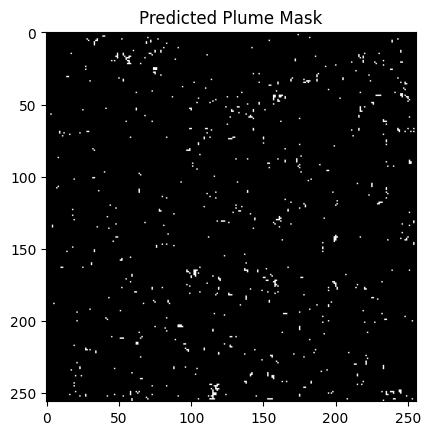

In [43]:
import matplotlib.pyplot as plt

plt.imshow(mask[0][0].cpu(), cmap="gray")
plt.title("Predicted Plume Mask")
plt.show()

In [44]:
import torch
import torch.nn as nn
import numpy as np

class FluxQuantificationPINN(nn.Module):
    def __init__(self):
        super(FluxQuantificationPINN, self).__init__()
        
        # CNN to extract features from the 2D Image 
        # Input Channels = 2 (Channel 1: Raw CH4 Data, Channel 2: Plume Mask from Stage 1)
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # Reduces 256x256 to 128x128
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # Reduces to 64x64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # Reduces to 32x32
            nn.Flatten()
        )
        
        # Calculate flattened size: 64 channels * 32 * 32 spatial dimensions
        self.fc_image = nn.Linear(64 * 32 * 32, 128)
        
        # Final layers: Combine image features with Wind Data
        self.fc_combined = nn.Sequential(
            # 128 (image features) + 2 (Wind U and V vectors)
            nn.Linear(128 + 2, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Predicts a single value: Q (Emission Rate in kg/hr)
        )

    def forward(self, x_images, wind_vectors):
        # 1. Process the satellite image and mask
        img_features = self.feature_extractor(x_images)
        img_features = torch.relu(self.fc_image(img_features))
        
        # 2. Concatenate image features with wind data (U, V)
        combined_features = torch.cat((img_features, wind_vectors), dim=1)
        
        # 3. Predict the Flux (Q)
        predicted_flux = self.fc_combined(combined_features)
        
        return predicted_flux

In [45]:
def physics_informed_loss(predicted_flux, actual_flux, plume_mass, wind_speed, plume_length, alpha=0.5):
    """
    alpha: Weight parameter. 
           alpha=0 means pure data-driven (Standard NN).
           alpha=1 means purely physics-driven.
           alpha=0.5 balances both.
    """
    mse_loss = nn.MSELoss()
    
    # 1. Data Loss: Model ka prediction vs actual labeled flux (agar available ho)
    data_loss = mse_loss(predicted_flux, actual_flux)
    
    # 2. Physics Loss: Equation of Mass Balance (IME Method)
    # Physics ke hisaab se flux kitna hona chahiye tha?
    # Equation: Q = (Mass * Wind) / Length
    physics_expected_flux = (plume_mass * wind_speed) / plume_length
    
    # Model ko force karo ki uska prediction is physics equation ke paas ho
    physics_loss = mse_loss(predicted_flux, physics_expected_flux)
    
    # 3. Total Loss
    total_loss = ((1 - alpha) * data_loss) + (alpha * physics_loss)
    
    return total_loss

In [46]:
# Initialization
model = FluxQuantificationPINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Dummy Data for 1 Batch (Size = 8)
# Image input: 8 samples, 2 channels, 256x256 dimensions
dummy_images = torch.rand(8, 2, 256, 256) 
# Wind input: 8 samples, 2 values (U_wind, V_wind)
dummy_wind = torch.rand(8, 2) * 5.0 # Random wind speeds up to 5 m/s

# Forward Pass
predicted_q = model(dummy_images, dummy_wind)

# To calculate Physics Loss, you need to extract these from your Stage 1 results:
# Total mass = sum of all CH4 pixels in the mask
dummy_mass = torch.tensor([[500.0]] * 8) 
dummy_wind_speed = torch.sqrt(dummy_wind[:, 0]**2 + dummy_wind[:, 1]**2).unsqueeze(1)
dummy_length = torch.tensor([[1500.0]] * 8) # in meters
dummy_actual_q = torch.tensor([[1200.0]] * 8) # Ground truth from Carbon Mapper (kg/hr)

# Calculate Loss & Backpropagate
loss = physics_informed_loss(
    predicted_flux=predicted_q,
    actual_flux=dummy_actual_q,
    plume_mass=dummy_mass,
    wind_speed=dummy_wind_speed,
    plume_length=dummy_length,
    alpha=0.6 # Giving 60% weight to physics, 40% to data
)

optimizer.zero_grad()
loss.backward()
optimizer.step()

print(f"Predicted Flux (First sample): {predicted_q[0].item():.2f} kg/hr")
print(f"Total PINN Loss: {loss.item():.4f}")

Predicted Flux (First sample): 0.03 kg/hr
Total PINN Loss: 575995.0625


In [47]:
import numpy as np

def estimate_occluded_source(plume_start_lat, plume_start_lon, wind_u, wind_v, cloud_cover_radius):
    """
    Agar badal hai, toh hawa ke opposite direction mein piche jao (Spatial Interpolation).
    wind_u: East-West wind vector (m/s)
    wind_v: North-South wind vector (m/s)
    """
    # Calculate wind direction angle
    wind_angle = np.arctan2(wind_v, wind_u)
    
    # Opposite direction mein back-trace karein (decay model)
    # cloud_cover_radius meters mein hai. Hum estimate karte hain plume wahan se shuru hua hoga.
    estimated_lat = plume_start_lat - (np.sin(wind_angle) * cloud_cover_radius * 0.00001) # Approx degree conversion
    estimated_lon = plume_start_lon - (np.cos(wind_angle) * cloud_cover_radius * 0.00001)
    
    return estimated_lat, estimated_lon

In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class SourceAttributionGNN(nn.Module):
    def __init__(self, node_feature_dim, hidden_dim):
        super(SourceAttributionGNN, self).__init__()
        
        # GraphSAGE layers - Spatial graph structure samajhne ke liye best hai
        self.conv1 = SAGEConv(node_feature_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        
        # Link Prediction ke liye (Plume aur Facility ke beech match probability)
        self.link_predictor = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid() # Output 0 se 1 ke beech (Confidence Score)
        )

    def forward(self, x, edge_index):
        # 1. Node Embeddings (Har facility aur plume ki spatial aukaat samajhna)
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = self.conv2(h, edge_index)
        
        return h # Returns embeddings for all nodes

    def predict_link(self, plume_embedding, facility_embedding):
        # 2. Probability nikalna ki kya ye plume isi facility se hai?
        combined = torch.cat([plume_embedding, facility_embedding], dim=-1)
        probability = self.link_predictor(combined)
        return probability

In [49]:
# --- Dummy Data Setup ---
# Maan lijiye humare paas 5 Facilities aur 2 Methane Plumes hain.
num_facilities = 5
num_plumes = 2

# Node Features: [Lat, Lon, Historical_Risk_Score, Plume_Flux (0 for facilities)]
# Total Feature Dimension = 4
facility_nodes = torch.rand((num_facilities, 4)) 
plume_nodes = torch.rand((num_plumes, 4))

# Combine all nodes into one Graph (X)
x = torch.cat([facility_nodes, plume_nodes], dim=0)

# --- Edge Creation Logic (The Secret Sauce) ---
# Hum sirf unhi facilities aur plumes ke beech edge banayenge jo 
# 1. Ek dusre ke paas hain (< 10km)
# 2. Facility Plume ke UPWIND direction mein hai (hawa facility se plume ki taraf ja rahi ho)
# (Yahan hum simplification ke liye manually edges define kar rahe hain)
source_nodes = torch.tensor([0, 1, 2, 3]) # Facility IDs
target_nodes = torch.tensor([5, 5, 6, 6]) # Plume IDs (5 and 6 because facilities are 0-4)

edge_index = torch.stack([source_nodes, target_nodes], dim=0)

# --- Model Initialization ---
gnn_model = SourceAttributionGNN(node_feature_dim=4, hidden_dim=32)

# --- Forward Pass ---
# Step A: Get Graph Embeddings
node_embeddings = gnn_model(x, edge_index)

# Step B: Check Attribution Match for Plume 1 (Node ID 5) and Facility 1 (Node ID 0)
plume_1_emb = node_embeddings[5]
facility_1_emb = node_embeddings[0]

match_confidence = gnn_model.predict_link(plume_1_emb, facility_1_emb)

print(f"Match Probability (Facility 1 -> Plume 1): {match_confidence.item() * 100:.2f}%")

Match Probability (Facility 1 -> Plume 1): 51.82%
